In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("dirty_cafe_sales.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 10000
Number of columns: 8


In [5]:


print(df.columns.tolist())

['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent', 'Payment Method', 'Location', 'Transaction Date']


In [6]:
df.dtypes

Transaction ID      str
Item                str
Quantity            str
Price Per Unit      str
Total Spent         str
Payment Method      str
Location            str
Transaction Date    str
dtype: object

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    10000 non-null  str  
 1   Item              9667 non-null   str  
 2   Quantity          9862 non-null   str  
 3   Price Per Unit    9821 non-null   str  
 4   Total Spent       9827 non-null   str  
 5   Payment Method    7421 non-null   str  
 6   Location          6735 non-null   str  
 7   Transaction Date  9841 non-null   str  
dtypes: str(8)
memory usage: 625.1 KB


In [8]:
df.describe()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_1961373,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


In [9]:


missing_values = df.isnull().sum()

print(missing_values)


Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64


In [10]:

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage

Transaction ID       0.00
Item                 3.33
Quantity             1.38
Price Per Unit       1.79
Total Spent          1.73
Payment Method      25.79
Location            32.65
Transaction Date     1.59
dtype: float64

In [11]:


missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": missing_percentage
})

missing_summary

,Missing Values,Missing Percentage
Transaction ID,0,0.00
Item,333,3.33
Quantity,138,1.38
Price Per Unit,179,1.79
Total Spent,173,1.73
Payment Method,2579,25.79
Location,3265,32.65
Transaction Date,159,1.59


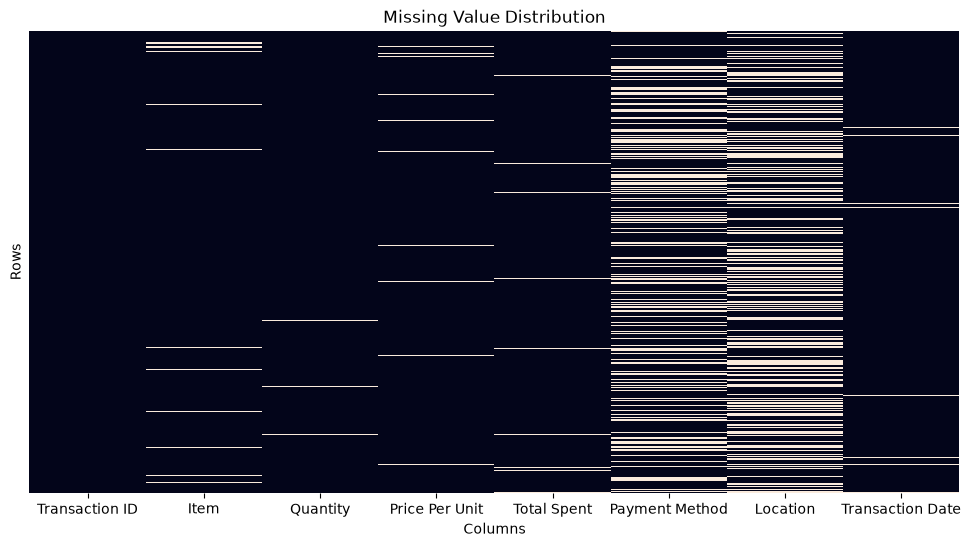

In [12]:


plt.figure(figsize=(12, 6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Value Distribution")
plt.xlabel("Columns")
plt.ylabel("Rows")

plt.show()

In [13]:
# Find the most frequent Item

item_mode = df["Item"].mode()[0]

print("Most frequent item:", item_mode)

Most frequent item: Juice


In [14]:
# Fill missing Item values with the most frequent item

df["Item"] = df["Item"].fillna(item_mode)

In [15]:
# Check remaining missing Item values

print("Missing Item values:", df["Item"].isnull().sum())

Missing Item values: 0


In [16]:
# Check unique values in Quantity

df["Quantity"].unique()

<StringArray>
['2', '4', '5', '3', '1', 'ERROR', 'UNKNOWN', nan]
Length: 8, dtype: str

In [20]:

# Convert Quantity from string to numeric

df["Quantity"] = pd.to_numeric(
    df["Quantity"],
    errors="coerce"
)


In [17]:
# Check unique values in Price Per Unit

df["Price Per Unit"].unique()

<StringArray>
['2.0', '3.0', '1.0', '5.0', '4.0', '1.5', nan, 'ERROR', 'UNKNOWN']
Length: 9, dtype: str

In [22]:
df["Price Per Unit"] = pd.to_numeric(
    df["Price Per Unit"],
    errors="coerce"
)

In [23]:
# Check unique values in Total Spent

df["Total Spent"].unique()

<StringArray>
[    '4.0',    '12.0',   'ERROR',    '10.0',    '20.0',     '9.0',    '16.0',
    '15.0',    '25.0',     '8.0',     '5.0',     '3.0',     '6.0',       nan,
 'UNKNOWN',     '2.0',     '1.0',     '7.5',     '4.5',     '1.5']
Length: 20, dtype: str

In [24]:
# Convert Total Spent to numeric

df["Total Spent"] = pd.to_numeric(
    df["Total Spent"],
    errors="coerce"
)

In [26]:
df["Transaction Date"].unique()

<StringArray>
['2023-09-08', '2023-05-16', '2023-07-19', '2023-04-27', '2023-06-11',
 '2023-03-31', '2023-10-06', '2023-10-28', '2023-07-28', '2023-12-31',
 ...
 '2023-08-01', '2023-01-20', '2023-11-11', '2023-02-13', '2023-07-30',
 '2023-02-17', '2023-05-20', '2023-11-05', '2023-03-27', '2023-07-03']
Length: 368, dtype: str

In [27]:
# Convert Transaction Date to datetime

df["Transaction Date"] = pd.to_datetime(
    df["Transaction Date"],
    errors="coerce"
)

In [28]:
df.dtypes

Transaction ID                 str
Item                           str
Quantity                   float64
Price Per Unit             float64
Total Spent                float64
Payment Method                 str
Location                       str
Transaction Date    datetime64[us]
dtype: object

In [29]:
# Fill missing Quantity values with the median

df["Quantity"] = df["Quantity"].fillna(
    df["Quantity"].median()
)

In [30]:
# Fill missing Price Per Unit values with the median

df["Price Per Unit"] = df["Price Per Unit"].fillna(
    df["Price Per Unit"].median()
)

In [31]:
# Calculate Total Spent using Quantity and Price Per Unit

calculated_total = (
    df["Quantity"] * df["Price Per Unit"]
)

df["Total Spent"] = df["Total Spent"].fillna(
    calculated_total
)

In [32]:
# Replace missing Payment Method values with Unknown

df["Payment Method"] = df["Payment Method"].fillna("Unknown")

In [34]:
# Replace missing Location values with Unknown

df["Location"] = df["Location"].fillna("Unknown")


In [35]:
# Compare missing values before and after treatment

comparison = pd.DataFrame({
    "Before Treatment": missing_values,
    "After Treatment": df.isnull().sum()
})

comparison

,Before Treatment,After Treatment
Transaction ID,0,0
Item,333,0
Quantity,138,0
Price Per Unit,179,0
Total Spent,173,0
Payment Method,2579,0
Location,3265,0
Transaction Date,159,460


In [36]:
# Display rows where Transaction Date is missing or invalid

df[df["Transaction Date"].isna()].head(20)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
11,TXN_3051279,Sandwich,2.0,4.0,8.0,Credit Card,Takeaway,NaT
29,TXN_7640952,Cake,4.0,3.0,12.0,Digital Wallet,Takeaway,NaT
33,TXN_7710508,UNKNOWN,5.0,1.0,5.0,Cash,Unknown,NaT
77,TXN_2091733,Salad,1.0,5.0,5.0,Unknown,In-store,NaT
103,TXN_7028009,Cake,4.0,3.0,12.0,Unknown,Takeaway,NaT
104,TXN_7447872,Juice,2.0,3.0,6.0,Unknown,Unknown,NaT
115,TXN_1001832,Salad,2.0,5.0,10.0,Cash,Takeaway,NaT
142,TXN_7943008,Coffee,1.0,2.0,2.0,Credit Card,Unknown,NaT
160,TXN_1093800,Sandwich,3.0,4.0,12.0,Cash,Takeaway,NaT
175,TXN_6463132,Cookie,5.0,1.0,5.0,Credit Card,Takeaway,NaT


## Treatment of Missing Transaction Dates

The Transaction Date column contained missing and invalid date entries. During conversion to datetime format, invalid date values were converted to NaT using errors="coerce".

After conversion, 460 records had missing or invalid transaction dates.

The missing dates were not replaced with an arbitrary date because the actual transaction dates could not be reliably determined from the available information. The NaT values were therefore retained to avoid introducing fabricated information into the dataset.

This approach preserves the integrity of the available data, although records with missing dates cannot be used for time-based analysis unless their dates are later recovered from the original source.

In [ ]:
# Count the missing/invalid transaction dates

print("Missing or invalid Transaction Dates:",
      df["Transaction Date"].isna().sum())

In [13]:
df.duplicated
print("the number of duplucated values:",df.duplicated().sum())

the number of duplucated values: 0


### Finding

The dataset contains no duplicate rows. Therefore, no duplicate records were removed.

In [39]:
# Check unique Item values

print(df["Item"].value_counts(dropna=False),"\n\n")
# Check unique Payment Method values

print(df["Payment Method"].value_counts(dropna=False),"\n\n")
# Check unique Location values

print(df["Location"].value_counts(dropna=False))


Item
Juice       1504
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
UNKNOWN      344
ERROR        292
Name: count, dtype: int64 


Payment Method
Unknown           2579
Digital Wallet    2291
Credit Card       2273
Cash              2258
ERROR              306
UNKNOWN            293
Name: count, dtype: int64 


Location
Unknown     3265
Takeaway    3022
In-store    3017
ERROR        358
UNKNOWN      338
Name: count, dtype: int64


In [40]:
# Standardize different forms of unknown values

for column in ["Item", "Payment Method", "Location"]:
    df[column] = df[column].replace(
        ["UNKNOWN", "unknown", "Unknown"],
        "Unknown"
    )

In [41]:
# Check whether different forms of Unknown still exist

for column in ["Item", "Payment Method", "Location"]:
    print("\n", column)
    print(df[column].value_counts(dropna=False))


 Item
Item
Juice       1504
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
Unknown      344
ERROR        292
Name: count, dtype: int64

 Payment Method
Payment Method
Unknown           2872
Digital Wallet    2291
Credit Card       2273
Cash              2258
ERROR              306
Name: count, dtype: int64

 Location
Location
Unknown     3603
Takeaway    3022
In-store    3017
ERROR        358
Name: count, dtype: int64


In [42]:
# Check minimum and maximum values of numerical columns

print("Quantity:")
print("Minimum:", df["Quantity"].min())
print("Maximum:", df["Quantity"].max())

print("\nPrice Per Unit:")
print("Minimum:", df["Price Per Unit"].min())
print("Maximum:", df["Price Per Unit"].max())

print("\nTotal Spent:")
print("Minimum:", df["Total Spent"].min())
print("Maximum:", df["Total Spent"].max())

Quantity:
Minimum: 1.0
Maximum: 5.0

Price Per Unit:
Minimum: 1.0
Maximum: 5.0

Total Spent:
Minimum: 1.0
Maximum: 25.0


In [43]:
# Count negative values in numerical columns

print("Negative Quantity:",
      (df["Quantity"] < 0).sum())

print("Negative Price Per Unit:",
      (df["Price Per Unit"] < 0).sum())

print("Negative Total Spent:",
      (df["Total Spent"] < 0).sum())

Negative Quantity: 0
Negative Price Per Unit: 0
Negative Total Spent: 0


In [44]:
# Calculate expected Total Spent

expected_total = (
    df["Quantity"] * df["Price Per Unit"]
)

In [45]:
# Calculate the difference between recorded and expected Total Spent

difference = (
    df["Total Spent"] - expected_total
)

print(difference.describe())

count    10000.000000
mean        -0.017400
std          1.403903
min        -10.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         16.000000
dtype: float64


In [46]:
# Identify records where Total Spent does not match Quantity × Price Per Unit

inconsistent_total = df[
    ~np.isclose(
        df["Total Spent"],
        expected_total,
        equal_nan=True
    )
]

print("Number of inconsistent Total Spent records:",
      len(inconsistent_total))

Number of inconsistent Total Spent records: 733


In [48]:
df.tail()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
9995,TXN_7672686,Coffee,2.0,2.0,4.0,Unknown,Unknown,2023-08-30
9996,TXN_9659401,Juice,3.0,3.0,3.0,Digital Wallet,Unknown,2023-06-02
9997,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,Unknown,2023-03-02
9998,TXN_7695629,Cookie,3.0,3.0,3.0,Digital Wallet,Unknown,2023-12-02
9999,TXN_6170729,Sandwich,3.0,4.0,12.0,Cash,In-store,2023-11-07


In [50]:
# Check remaining missing values

df.isnull().sum()

Transaction ID        0
Item                  0
Quantity              0
Price Per Unit        0
Total Spent           0
Payment Method        0
Location              0
Transaction Date    460
dtype: int64